In [158]:
import pandas as pd
import matplotlib.pyplot as plt


In [159]:
df=pd.read_csv('alayta_bank_data.csv')
df.head()

,CustomerID,CustomerName,LoanID,LoanAmount,LoanInterestRate,LoanDuration,LoanStartDate,OfficerID,OfficerName,OfficerPhone,OfficerEmail,BranchID,BranchName,BranchAddress,PaymentID,PaymentDate,PaymentAmount,TransactionID,TransactionDate,TransactionType
0,88,Nicole Pena,148,6723.11,8.24,24 months,2022-09-24,7,Katherine Dennis,999.798.3635x80775,jessewalker@example.net,11,Shaw Ltd,USCGC Whitney\nFPO AP 34274,4028,2024-01-17,405.12,4873,2024-01-17,Principal Payment
1,434,Matthew Holmes,200,27375.26,4.35,36 months,2023-10-04,31,Angela Bennett,+1-242-684-4907,cody43@example.net,7,Castillo-Bell,"358 Connie Fort Apt. 573\nKimchester, ME 83801",1453,2024-03-01,2619.69,5876,2024-03-01,Interest Payment
2,64,Christian Blair,412,30519.88,4.10,48 months,2022-12-22,35,Chad Walker,(816)957-8642x934,samanthaphillips@example.org,7,"Harris, Randolph and Johns",USS Sullivan\nFPO AP 14466,5478,2023-11-26,2882.62,7023,2023-11-26,Interest Payment
3,430,James Allen,300,38167.50,8.14,36 months,2020-05-01,10,Daniel Holmes,9538673266,patricksimmons@example.org,19,"Hayes, Wilson and Taylor","24435 Gomez Ville\nNew Christinaborough, GU 54053",5335,2023-11-29,418.59,4580,2023-11-29,Interest Payment
4,57,Kristin Reyes,33,11355.12,4.16,48 months,2020-01-23,1,Francisco Barton,570-874-2272x9540,brianwade@example.net,2,Brown Group,"7573 Cassidy Ports\nDanielview, DE 97424",3527,2022-02-17,128.40,2016,2022-02-17,Loan Payment


# EDA

In [160]:
df.shape 

(1000, 20)

In [161]:
df.info() # Data has no null values and all data types are correct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1000 non-null   int64  
 1   CustomerName      1000 non-null   object 
 2   LoanID            1000 non-null   int64  
 3   LoanAmount        1000 non-null   float64
 4   LoanInterestRate  1000 non-null   float64
 5   LoanDuration      1000 non-null   object 
 6   LoanStartDate     1000 non-null   object 
 7   OfficerID         1000 non-null   int64  
 8   OfficerName       1000 non-null   object 
 9   OfficerPhone      1000 non-null   object 
 10  OfficerEmail      1000 non-null   object 
 11  BranchID          1000 non-null   int64  
 12  BranchName        1000 non-null   object 
 13  BranchAddress     1000 non-null   object 
 14  PaymentID         1000 non-null   int64  
 15  PaymentDate       1000 non-null   object 
 16  PaymentAmount     1000 non-null   float64
 

In [162]:
df[['OfficerID','BranchID']].duplicated().sum() 

# There is duplicated values this mean the branch and officer details is duplcated and did not have 
# a unique value for each customer so we can remove the branch and officer details from the data model
# and keep only the ids to link them together 

np.int64(349)

In [163]:
df[['CustomerID', 'OfficerID']].duplicated().sum()

np.int64(20)

In [164]:
df[['CustomerID', 'BranchID']].duplicated().sum()


np.int64(50)

In [165]:
df[['TransactionID', 'CustomerID','LoanID']].duplicated().sum()

np.int64(0)

In [166]:
df['TransactionID'].duplicated().sum()

np.int64(42)

# Data Preprocessing and Data Cleaning

In [167]:

df["BranchAddress"] =df["BranchAddress"].str.replace(r"\n", ", ", regex=True).str.strip()

##### we need to normalize the data to make it more efficient and easier to query


### 1NF: atomic values, no repeating groups
### Adding primary key(record_id) 
### composite key will be ('TransactionID', 'CustomerID','LoanID')

# 2NF
### Must be in 1NF, and every non-key attribute must depend on the whole 
### composite key (CustomerID, LoanID, TransactionID) — not just part of it.

# Tables in 2NF will be: 
- customers Table >> CustomerID(PK), CustomerName
- branch table >> BranchID(PK), BranchName, BranchAddress
- officers table >> OfficerID(PK), OfficerName, OfficerPhone, OfficerEmail, BranchID(FK)
- loans table >> LoanID(PK), LoanAmount, LoanInterestRate, LoanDuration, LoanStartDate ,CustomerID(FK), OfficerID(FK)
- payments table >> PaymentID(PK), LoanID(FK), PaymentDate, PaymentAmount
- transactions table >>TransactionID(PK), LoanID(FK), TransactionDate, TransactionType

In [168]:
customers = (
    df[['CustomerID', 'CustomerName']]
    .drop_duplicates(subset=['CustomerID'])
    .sort_values('CustomerID')
    .reset_index(drop=True)
)
customers.head()


,CustomerID,CustomerName
0,1,Catherine Hansen
1,5,Jeanette Cook
2,6,Thomas White
3,7,Justin Gomez
4,8,Stephen Smith


In [169]:
branch = (
    df[['BranchID', 'BranchName', 'BranchAddress']]
    .drop_duplicates(subset=['BranchID'])
    .sort_values('BranchID')
    .reset_index(drop=True)
)
branch.head()

,BranchID,BranchName,BranchAddress
0,1,Phillips-Atkins,"97184 Savage Points, East Kristina, MP 07842"
1,2,Brown Group,"7573 Cassidy Ports, Danielview, DE 97424"
2,3,Rich-Baxter,"8204 Kimberly Islands Suite 355, Sherrybury, K..."
3,4,Boyd-Young,"567 Theodore Springs, Lake Kimberly, PA 09304"
4,5,Hughes Ltd,"32458 Cory Plains, Valentineshire, PA 90367"


In [170]:
officers = (
    df[['OfficerID', 'OfficerName', 'OfficerPhone', 'OfficerEmail', 'BranchID']]
    .drop_duplicates(subset=['OfficerID'])
    .sort_values('OfficerID')
    .reset_index(drop=True)
)
officers.head()

,OfficerID,OfficerName,OfficerPhone,OfficerEmail,BranchID
0,1,Francisco Barton,570-874-2272x9540,brianwade@example.net,2
1,2,Chad Patel,843-668-9649,catherine82@example.com,12
2,3,Blake Garcia,721.206.8224x002,meghan78@example.com,9
3,4,Mary Bonilla,(636)554-0584,ijones@example.net,17
4,5,Roger Edwards,680.900.9943,garrettvargas@example.net,17


In [171]:
loans = (
    df[['LoanID', 'LoanAmount', 'LoanInterestRate',
        'LoanDuration', 'LoanStartDate', 'CustomerID', 'OfficerID']]
    .drop_duplicates(subset=['LoanID'])
    .sort_values('LoanID')
    .reset_index(drop=True)
)
loans.head()

,LoanID,LoanAmount,LoanInterestRate,LoanDuration,LoanStartDate,CustomerID,OfficerID
0,1,6444.76,7.41,24 months,2022-09-14,278,37
1,2,37769.66,8.62,48 months,2024-08-31,243,13
2,3,21803.31,7.79,24 months,2020-07-14,198,24
3,6,7607.21,7.95,24 months,2020-06-18,191,29
4,7,12821.91,8.37,24 months,2022-04-08,263,5


In [172]:
payments = (
    df[['PaymentID', 'PaymentDate', 'PaymentAmount', 'LoanID']]
    .drop_duplicates(subset=['PaymentID'])
    .sort_values('PaymentID')
    .reset_index(drop=True)
)
payments.head()

,PaymentID,PaymentDate,PaymentAmount,LoanID
0,27,2022-12-19,674.22,185
1,43,2024-07-28,112.08,428
2,70,2023-07-28,2016.74,585
3,86,2024-05-09,919.64,750
4,88,2023-05-06,2129.37,422


In [173]:
transactions = (
    df[['TransactionID', 'TransactionDate', 'TransactionType', 'LoanID']]
    .drop_duplicates(subset=['TransactionID'])
    .sort_values('TransactionID')
    .reset_index(drop=True)
)
transactions.head()

,TransactionID,TransactionDate,TransactionType,LoanID
0,8,2024-08-22,Loan Payment,945
1,9,2024-09-23,Principal Payment,306
2,50,2023-10-11,Loan Payment,471
3,51,2023-12-12,Principal Payment,66
4,74,2023-09-14,Principal Payment,862


# Conver 2NF to 3NF
##### No transitive dependencies are existed and each table is related to its unique primary key so dataset is fully normalized to 3NF

# Load data to PostgresSql

In [174]:
import psycopg2
conn = psycopg2.connect(
    host     = "localhost",
    port     = 5432,
    database = "alayta_bank",
    user     = "postgres",
    password = "12345"
)
cursor=conn.cursor()

In [175]:
# Create tables
cursor=conn.cursor()
cursor.execute("""
                drop table if exists customers cascade;
                drop table if exists loans cascade;
                drop table if exists officers cascade;
                drop table if exists branch cascade;
                drop table if exists payments cascade;
                drop table if exists transactions cascade;
               
                create table customers (
                    CustomerID   int primary key,
                    CustomerName varchar(255)
                );
               
                create table branch (
                    BranchID      int primary key,
                    BranchName    varchar(255),
                    BranchAddress varchar(255)
                );
               
                create table officers (
                    OfficerID    int primary key,
                    OfficerName  varchar(255),
                    OfficerPhone varchar(255),
                    OfficerEmail varchar(255),
                    BranchID     int references branch(BranchID)
                );
               
                create table loans (
                    LoanID           int primary key,
                    LoanAmount       float,
                    LoanInterestRate float,
                    LoanDuration     varchar(255),
                    LoanStartDate   date,
                    CustomerID      int references customers(CustomerID),
                    OfficerID       int references officers(OfficerID)
                );
               
                create table payments (
                    PaymentID   int primary key,
                    PaymentDate date,
                    PaymentAmount float,
                    LoanID      int references loans(LoanID)
                );
               
                create table transactions (
                    TransactionID   int primary key,
                    TransactionDate date,
                    TransactionType varchar(255),
                    LoanID         int,
                    FOREIGN KEY (LoanID) REFERENCES loans(LoanID)
                );
    
""")
conn.commit()
print("Tables created successfully")

Tables created successfully


# ERD Diagram
<img src="ERD Diagram.png" width="100%">

In [176]:
# insert data into tables
cursor=conn.cursor()
def insert_table(table_name, dataframe):
    columns = ', '.join([f'{c}' for c in dataframe.columns])
    placeholders = ', '.join(['%s'] * len(dataframe.columns))
    query = f'insert into {table_name} ({columns}) values ({placeholders})'

    records = list(dataframe.itertuples(index=False, name=None))
    cursor.executemany(query, records)
    print(f"Inserted {len(records)} rows into '{table_name}'")


insert_table('customers', customers)
insert_table('branch', branch)
insert_table('officers', officers)
insert_table('loans', loans)
insert_table('payments', payments)
insert_table('transactions', transactions)
conn.commit()
print("All data inserted successfully")

Inserted 435 rows into 'customers'
Inserted 20 rows into 'branch'
Inserted 50 rows into 'officers'
Inserted 634 rows into 'loans'
Inserted 963 rows into 'payments'
Inserted 958 rows into 'transactions'
All data inserted successfully


In [177]:
# select count from Customers to verify data insertion
cursor.execute("select count(*) from customers")
print("Number of rows in customers:", cursor.fetchone()[0])

Number of rows in customers: 435


# Visualization

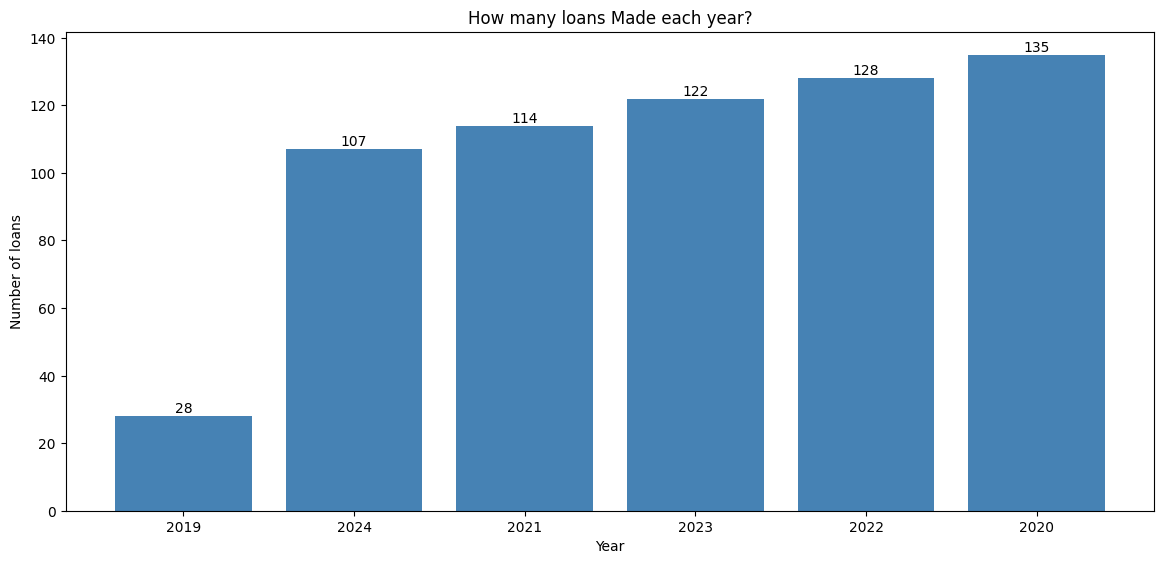

In [178]:
conn.cursor()
cursor.execute("""
    select extract(year from LoanStartDate) as loan_year,
           count(LoanID) as loan_count
    from loans
    group by loan_year
    order by loan_count
""")
loans_per_year = pd.DataFrame(cursor.fetchall(), columns=['LoanYear', 'NumberOfLoans'])

plt.figure(figsize=(12, 6))
plt.bar(
    loans_per_year['LoanYear'].astype(str),
    loans_per_year['NumberOfLoans'],
    color='steelblue'
)
plt.title('How many loans Made each year?')
plt.xlabel('Year')
plt.ylabel('Number of loans')
for i, v in enumerate(loans_per_year['NumberOfLoans']):
    plt.text(i, v + 1, str(v), ha='center')

plt.tight_layout(pad=2)
plt.show()

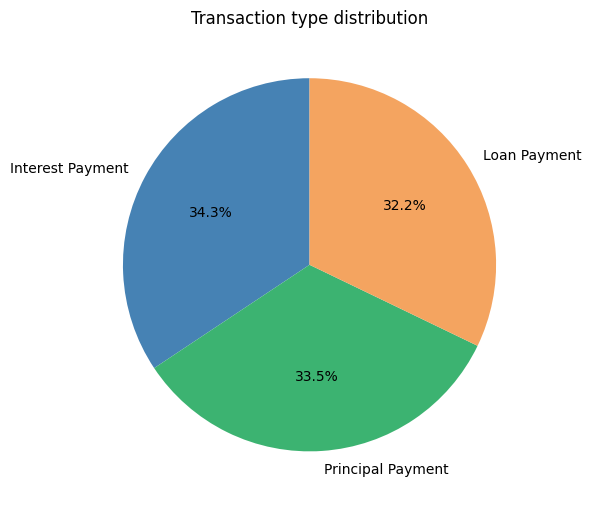

In [179]:
conn.cursor()
cursor.execute("""
    select TransactionType,
           COUNT(TransactionID) as TransactionCount
    from transactions
    group by TransactionType
    order by TransactionCount desc
""")
transaction_types = pd.DataFrame(cursor.fetchall(), columns=['TransactionType', 'TransactionCount'])

plt.figure(figsize=(6, 6))
plt.pie(transaction_types['TransactionCount'], labels=transaction_types['TransactionType'], autopct='%1.1f%%',
        colors=['steelblue', 'mediumseagreen', 'sandybrown'],
        startangle=90)
plt.title('Transaction type distribution')
plt.tight_layout()
plt.show()

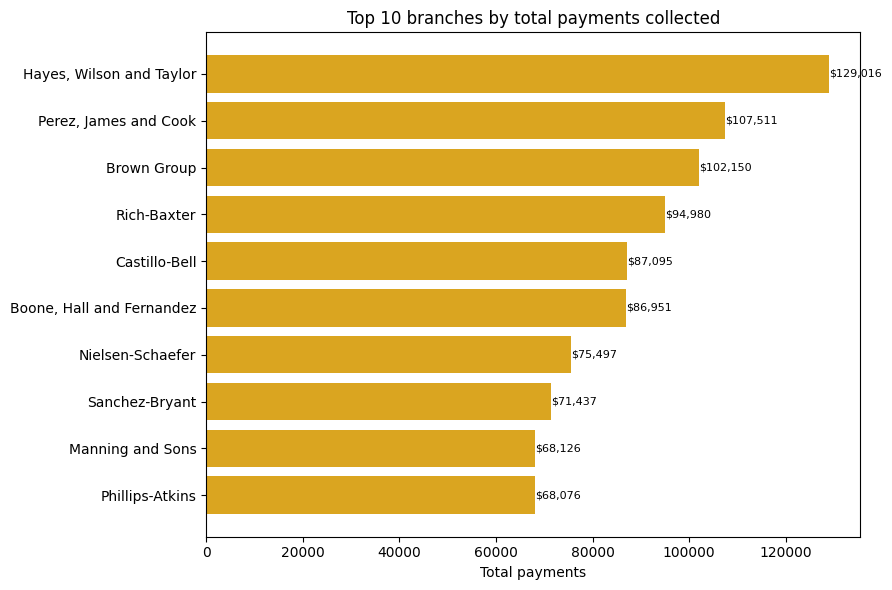

In [180]:
conn.cursor()
cursor.execute("""
    select b.BranchName,
           round(sum(p.PaymentAmount)::numeric, 2) as total_payments
    from payments p
    join loans l on p.LoanID    = l.LoanID
    join officers o on l.OfficerID = o.OfficerID
    join branch b on o.BranchID  = b.BranchID
    group by b.BranchName
    order by total_payments desc
    limit 10
""")
BranchesPayments = pd.DataFrame(cursor.fetchall(), columns=['BranchName', 'TotalPayments'])

plt.figure(figsize=(9, 6))
plt.barh(BranchesPayments['BranchName'].iloc[::-1], BranchesPayments['TotalPayments'].iloc[::-1], color='goldenrod')
plt.title('Top 10 branches by total payments collected')
plt.xlabel('Total payments')
for i, v in enumerate(BranchesPayments['TotalPayments'].iloc[::-1]):
    plt.text(v + 20, i, f'${v:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

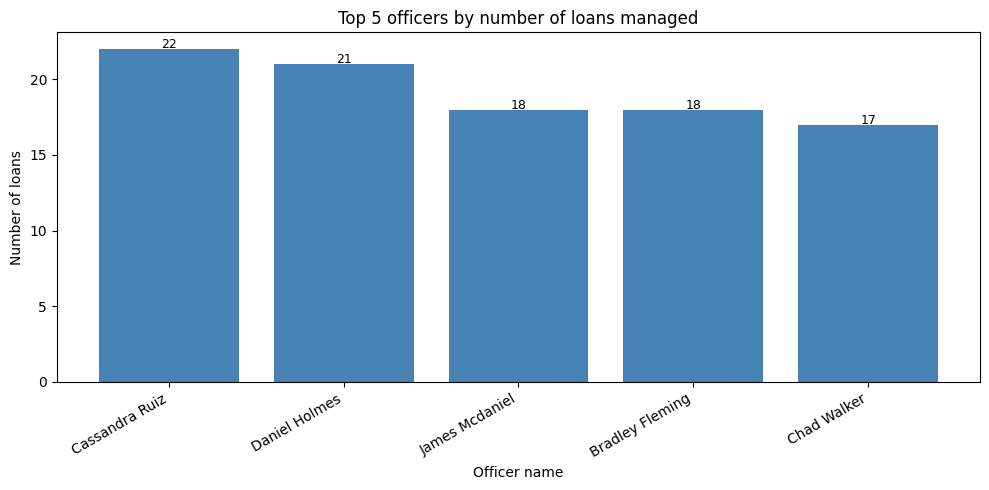

In [181]:
# top 5 officers worked on the most loans
cursor.execute("""
    select o.OfficerName,
           count(l.LoanID) as loan_count
    from loans    l
    join officers o on l.OfficerID = o.OfficerID
    group by o.OfficerName
    order by loan_count desc
    limit 5
""")
OfficersLoans = pd.DataFrame(cursor.fetchall(), columns=['OfficerName', 'LoanCount'])

plt.figure(figsize=(10, 5))
plt.bar(OfficersLoans['OfficerName'], OfficersLoans['LoanCount'], color='steelblue')
plt.title('Top 5 officers by number of loans managed')
plt.xlabel('Officer name')
plt.ylabel('Number of loans')
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(OfficersLoans['LoanCount']):
    plt.text(i, v + 0.05, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()